In [1]:
import Pkg;
Pkg.activate(@__DIR__);
Pkg.instantiate();

  Activating project at `~/OneDrive_xwc@zju.edu.cn/optimal-control/my-notes/code/with-notes/lec5`


In [2]:
using LinearAlgebra
using ForwardDiff
using PyPlot
using LaTeXStrings
using JupyterFormatter
enable_autoformat()
PyPlot.rc("text", usetex = true)
PyPlot.rc("font", family = "Times New Roman")
PyPlot.rc("text.latex", preamble = "\\usepackage{{amsmath}}")

In [3]:
Q = Diagonal([0.5; 1])
function f(x)
    return 0.5 * (x - [1; 0])' * Q * (x - [1; 0])
end
gradient_f = x -> ForwardDiff.gradient(x -> f(x), x);
hessian_f = x -> ForwardDiff.hessian(x -> f(x), x);

In [4]:
A = [1.0 -1.0]
b = -1.0
function c(x)
    return dot(A, x) - b
end
gradient_c = x -> ForwardDiff.gradient(x -> c(x), x);

In [5]:
let
    x0 = [0, 0]
    @show f(x0)
    @show gradient_f(x0)
    @show hessian_f(x0)
    @show c(x0)
    @show gradient_c(x0)
end;

f(x0) = 0.25
gradient_f(x0) = [-0.5, 0.0]
hessian_f(x0) = [0.5 0.0; 0.0 1.0]
c(x0) = 1.0
gradient_c(x0) = [1.0, -1.0]


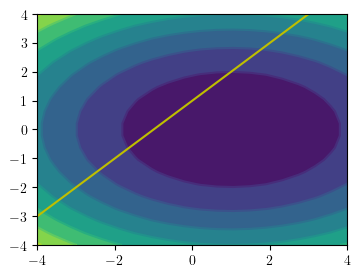

In [6]:
function plot_landscape()
    n_sample = 20
    x_sample = kron(ones(n_sample), LinRange(-4, 4, n_sample)')
    y_sample = kron(ones(n_sample)', LinRange(-4, 4, n_sample))
    z = [f([x, y]) for (x, y) in zip(x_sample, y_sample)]
    figure(figsize = (4, 3))
    contourf(x_sample, y_sample, z)
    contour(x_sample, y_sample, z)
    xc = LinRange(-4, 4, n_sample)
    plot(xc, [c([x 0]) for x in xc], "y")
    xlim([-4, 4])
    ylim([-4, 4])
end
plot_landscape();

In [7]:
function lagrangian(x0, lambda, rho)
    p = max(0, c(x0))
    return f(x0) + lambda * p + rho / 2 * p' * p
end

lagrangian (generic function with 1 method)

In [8]:
function newton(x0, lambda, rho)
    x = x0
    p = max.(0, c(x))
    C = [0; 0]
    if c(x) > 0
        C = gradient_c(x)
    end
    g = gradient_f(x) + (lambda + rho * p) * C
    while norm(g) > 1e-8  # optimization w.r.t. x first
        H = hessian_f(x) + rho * C * C'
        delta_x = -H \ g
        x = x + delta_x
        p = max.(0, c(x))
        C = [0; 0]
        if c(x) > 0
            C = gradient_c(x)
        end
        g = gradient_f(x) + (lambda + rho * p) * C
    end
    return x
end

newton (generic function with 1 method)

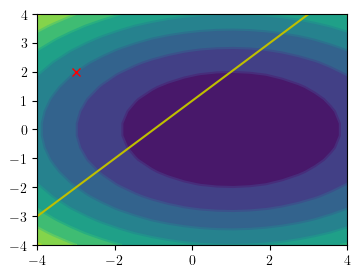

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f752494ad50>

In [9]:
x_guess = [-3; 2]
lambda_guess = [0.0]
rho = 1.0
plot_landscape()
plot(x_guess[1], x_guess[2], "rx")

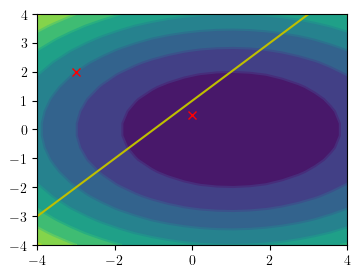

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f75396a89d0>

In [10]:
x_new = newton(x_guess[:, end], lambda_guess[end], rho)
lambda_new = max.(0, lambda_guess[end] + rho * c(x_new))
x_guess = [x_guess x_new]
lambda_guess = [lambda_guess lambda_new]  # comment this and see what will happen
rho = 10 * rho  # comment this and see what will happen
plot_landscape()
plot(x_guess[1, :], x_guess[2, :], "rx")